# NLP and Sequence Modeling Mini Project

This notebook builds a basic NLP pipeline for customer support sentiment classification and compares traditional text vectorization with sequence-based deep learning.

Dataset: Customer Support Text Classification  
Target: `sentiment_label`  
Input text: `customer_message`

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
DATA_PATH = "customer_support_text_classification.csv"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# Basic cleanup
df = df.dropna(subset=["customer_message", "sentiment_label"]).copy()
df["customer_message"] = df["customer_message"].astype(str)

print("Loaded shape:", df.shape)
print(df.head())

Loaded shape: (1500, 6)
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


## Task 1: Dataset Understanding

In this section, we inspect:
- Number of records
- Target labels/classes
- Sample text records
- Average text length
- Class distribution

In [2]:
print("Number of records:", len(df))
print("\nColumns:", df.columns.tolist())
print("\nTarget classes:", df["sentiment_label"].unique().tolist())

print("\nClass distribution:")
print(df["sentiment_label"].value_counts())

print("\nClass distribution (%):")
print((df["sentiment_label"].value_counts(normalize=True) * 100).round(2))

print("\nSample text records:")
print(df[["customer_message", "sentiment_label"]].head(5).to_string(index=False))

df["text_length"] = df["customer_message"].str.split().str.len()
print("\nAverage text length (words):", round(df["text_length"].mean(), 2))
print("Min length:", int(df["text_length"].min()))
print("Max length:", int(df["text_length"].max()))

Number of records: 1500

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target classes: ['neutral', 'positive', 'negative']

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Class distribution (%):
sentiment_label
neutral     34.93
negative    33.13
positive    31.93
Name: proportion, dtype: float64

Sample text records:
                                                                                            customer_message sentiment_label
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.         neutral
                                                               I need information about the payment process.         neutral
                                The refund process was fast and convenient. I appreciate the quick response.        positive
                   My refund is still pending and this expe

## Task 2: Text Preprocessing

Preprocessing steps:
- Lowercasing
- Removing unnecessary symbols and special characters
- Tokenization
- Removing stopwords
- Preparing text for vectorization and sequence modeling

In [3]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # remove links
    text = re.sub(r"[^a-z\s]", " ", text)            # keep letters only
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    tokens = [tok for tok in text.split() if tok not in stop_words and len(tok) > 1]
    return " ".join(tokens)

df["clean_text"] = df["customer_message"].apply(clean_text)

print(df[["customer_message", "clean_text"]].head(10).to_string(index=False))

                                                                                            customer_message                                                           clean_text
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible. need information payment process ticket number respond soon possible
                                                               I need information about the payment process.                                     need information payment process
                                The refund process was fast and convenient. I appreciate the quick response.             refund process fast convenient appreciate quick response
                   My refund is still pending and this experience is frustrating. My ticket number is 33927.                  refund pending experience frustrating ticket number
                                                            Please tell me how to update my account details.  

## Task 3: Text Vectorization

Raw text cannot be used directly by most machine learning models.  
It must be converted into numeric form because models perform mathematical operations on numbers, not strings.

In this notebook, we use:
- TF-IDF for the baseline model
- Tokenizer + padded sequences for the sequence model

In [4]:
# Train-test split
X_train_text, X_test_text, y_train_str, y_test_str = train_test_split(
    df["clean_text"],
    df["sentiment_label"],
    test_size=0.2,
    random_state=SEED,
    stratify=df["sentiment_label"]
)

# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_str)
y_test = label_encoder.transform(y_test_str)

class_names = label_encoder.classes_.tolist()
print("Label mapping:")
for i, cls in enumerate(class_names):
    print(i, "->", cls)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

Label mapping:
0 -> negative
1 -> neutral
2 -> positive
TF-IDF train shape: (1200, 395)
TF-IDF test shape: (300, 395)


## Task 4: Baseline Model

Baseline model:
- TF-IDF + Logistic Regression

This gives a strong, simple benchmark for text classification.

Baseline Accuracy: 1.0
Baseline Macro F1: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



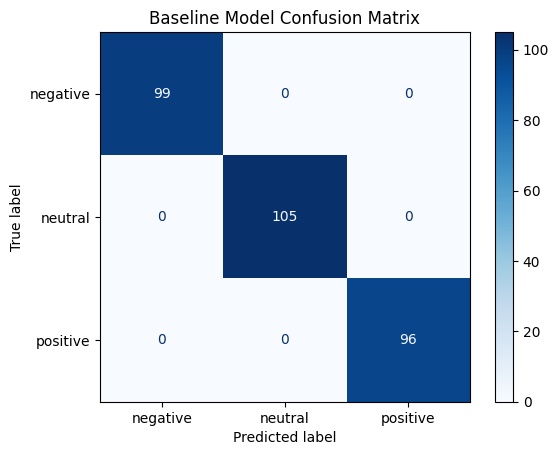

In [5]:
baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train_tfidf, y_train)

baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="macro")

print("Baseline Accuracy:", round(baseline_acc, 4))
print("Baseline Macro F1:", round(baseline_f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, baseline_pred, target_names=class_names, zero_division=0))

baseline_cm = confusion_matrix(y_test, baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Model Confusion Matrix")
plt.show()

## Task 5: Sequence Model Using LSTM

Conceptual flow:
- Input sequence
- Embedding layer
- LSTM layer
- Dense output layer
- Loss function: sparse categorical cross-entropy
- Evaluation metric: accuracy

Sequence models preserve word order, which helps the model learn context better than plain bag-of-words methods.

In [6]:
# Tokenizer-based sequences
MAX_VOCAB = 10000
MAX_LEN = 30

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded train shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)

# LSTM model
seq_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(len(class_names), activation="softmax")
])

seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq_model.summary()

Padded train shape: (1200, 30)
Padded test shape: (300, 30)


c:\Users\rkp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.3427 - loss: 1.1019 - val_accuracy: 0.3042 - val_loss: 1.1002
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3458 - loss: 1.0986 - val_accuracy: 0.3042 - val_loss: 1.0946
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5875 - loss: 0.7874 - val_accuracy: 0.6417 - val_loss: 0.4981
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6760 - loss: 0.4658 - val_accuracy: 0.6417 - val_loss: 0.4655
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6729 - loss: 0.4558 - val_accuracy: 0.6417 - val_loss: 0.4659
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6583 - loss: 0.4564 - val_accuracy: 0.6417 - val_loss: 0.4647
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6760 - loss: 0.4538 - val_accuracy: 0.6417 - val_loss: 0.4617
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6917 - loss: 0.4517 - val_accuracy: 0.6417 - 

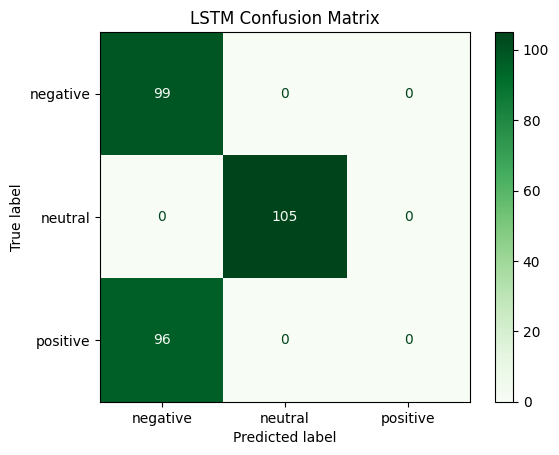

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = seq_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

seq_loss, seq_acc = seq_model.evaluate(X_test_pad, y_test, verbose=0)
seq_pred_probs = seq_model.predict(X_test_pad, verbose=0)
seq_pred = np.argmax(seq_pred_probs, axis=1)

seq_f1 = f1_score(y_test, seq_pred, average="macro")

print("LSTM Test Accuracy:", round(seq_acc, 4))
print("LSTM Macro F1:", round(seq_f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, seq_pred, target_names=class_names, zero_division=0))

seq_cm = confusion_matrix(y_test, seq_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=seq_cm, display_labels=class_names)
disp.plot(cmap="Greens", values_format="d")
plt.title("LSTM Confusion Matrix")
plt.show()

In [8]:
# Save evaluation comparison
evaluation_df = pd.DataFrame([
    {
        "model": "Logistic Regression + TF-IDF",
        "accuracy": baseline_acc,
        "macro_f1": baseline_f1
    },
    {
        "model": "LSTM + Tokenizer Sequences",
        "accuracy": seq_acc,
        "macro_f1": seq_f1
    }
])

evaluation_df.to_csv(os.path.join(RESULTS_DIR, "model_evaluation.csv"), index=False)
print(evaluation_df)

                          model  accuracy  macro_f1
0  Logistic Regression + TF-IDF      1.00  1.000000
1    LSTM + Tokenizer Sequences      0.68  0.557823


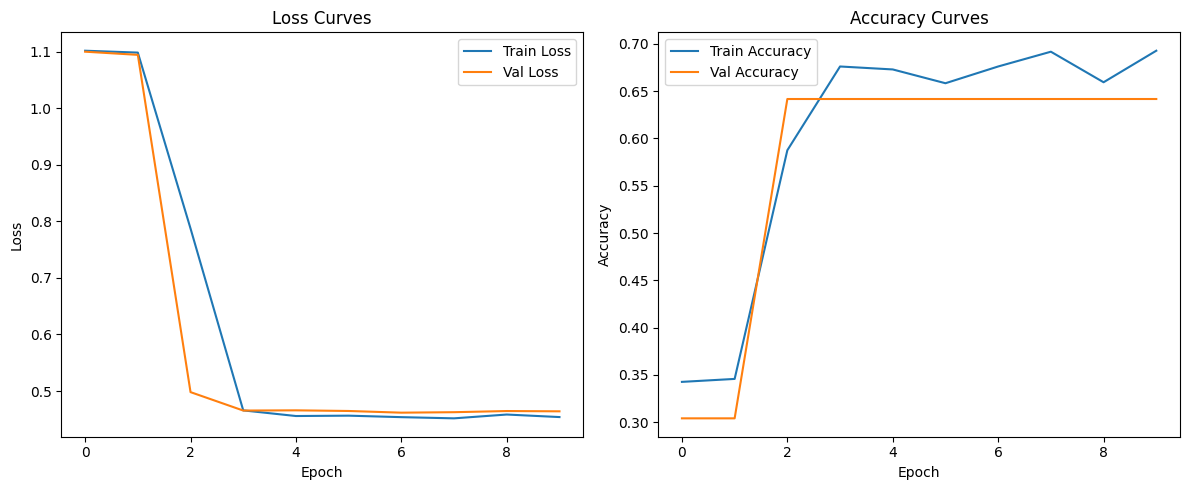

In [9]:
# Save training curves as model_evaluation.png
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_evaluation.png"), dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# Save sample predictions
sample_n = min(10, len(X_test_text))
sample_indices = np.random.choice(len(X_test_text), size=sample_n, replace=False)

sample_texts = X_test_text.iloc[sample_indices].tolist()
sample_true = label_encoder.inverse_transform(y_test[sample_indices])
sample_pred_labels = label_encoder.inverse_transform(seq_pred[sample_indices])

sample_file = os.path.join(RESULTS_DIR, "sample_predictions.txt")

with open(sample_file, "w", encoding="utf-8") as f:
    for i, (text, true_label, pred_label) in enumerate(zip(sample_texts, sample_true, sample_pred_labels), start=1):
        f.write(f"Sample {i}\n")
        f.write(f"Text: {text}\n")
        f.write(f"True Label: {true_label}\n")
        f.write(f"Predicted Label: {pred_label}\n")
        f.write("-" * 80 + "\n")

print(f"Saved sample predictions to: {sample_file}")

Saved sample predictions to: results\sample_predictions.txt


## Task 6: Attention and Transformer Reflection

### Why RNNs struggle with long-term dependencies
RNNs process one word at a time and must carry information through many steps.  
This makes it difficult to preserve earlier context, especially in long sequences, because gradients can vanish or become unstable during training.

### How LSTMs help with memory
LSTMs add gates that control what to remember, what to forget, and what to output.  
This allows them to retain useful information for longer and improves performance on sequence tasks.

### What attention solves in sequence-to-sequence tasks
Attention lets the model focus on the most relevant parts of the input while generating each output token.  
Instead of compressing everything into a single hidden state, it dynamically looks back at important words.

### Why transformers are important in modern NLP and Generative AI
Transformers rely on self-attention, so they can model relationships between all tokens in parallel.  
They are faster to train than RNNs, capture long-range dependencies better, and form the basis of modern NLP and generative AI systems.